# Step 3: Exploratory Data Analysis (EDA)

Questo notebook esplora i dati tramite visualizzazioni.

Scopri:
- Trend dei dati nel tempo
- Disponibilità dei dati
- Distribuzione degli indicatori
- Correlazioni tra variabili

In [1]:
# SETUP: Configure Python path to find src/ module
import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_root = notebook_dir.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"✓ Added to sys.path: {project_root}")

print(f"✓ Project root: {project_root}")
print(f"✓ src/ module should be at: {project_root}/src")

✓ Added to sys.path: /Users/valerioquaranta/Documents/Data Science/Development/Data Visualization/project_data_manipulation
✓ Project root: /Users/valerioquaranta/Documents/Data Science/Development/Data Visualization/project_data_manipulation
✓ src/ module should be at: /Users/valerioquaranta/Documents/Data Science/Development/Data Visualization/project_data_manipulation/src


In [2]:
# Importa moduli
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import (
    load_education_data,
    get_correlation_matrix,
    get_summary_statistics
)
from src.visualization import (
    plot_trends_by_country,
    plot_correlation_heatmap,
    plot_data_availability,
    plot_mean_indicators,
    plot_box_distribution
)
from src.config import DATA_PROCESSED_DIR, MIN_YEAR

# Setup plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Modules loaded successfully!")

✓ Loaded environment variables from .env file
Modules loaded successfully!


In [3]:
# Carica i dati puliti dal notebook precedente
df_clean = pd.read_csv(DATA_PROCESSED_DIR / "df_clean.csv")

print(f"Dataset loaded: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")

Dataset loaded: (235, 9)

Columns: ['Country Name', 'Country Code', 'Year', 'Secondary Completion Rate (%)', 'Education Expenditure (% of GDP)', 'Primary Enrolment Rate(%)', 'GDP per Capita', 'Life Expectancy (Years)', 'Infant Mortality Rate (per 1000 live births)']


In [4]:
# Statistiche descrittive per paese
print("\nSummary Statistics by Country:")
print("="*80)
get_summary_statistics(df_clean, by_country=True).round(2)


Summary Statistics by Country:


Primary Enrolment Rate(%)                                    \
                                  count   mean   std    min    25%    50%   
Country Name                                                                
Australia                          24.0  99.27  1.09  95.29  99.43  99.69   
Brazil                             23.0  94.76  0.74  94.18  94.18  94.18   
Canada                             23.0  98.94  0.98  96.29  98.90  99.42   
China                              24.0  99.91  0.00  99.91  99.91  99.91   
Germany                            24.0  98.70  0.54  97.72  98.36  98.65   
India                              24.0  95.51  4.48  83.01  93.57  97.15   
Italy                              24.0  99.16  0.63  98.33  98.42  99.59   
Kenya                              22.0  83.54  6.79  64.96  83.38  83.38   
South Africa                       24.0  89.93  4.46  79.78  87.65  91.32   
United States                      23.0  98.50  1.11  95.90  97.98  98.85   

                            Secondary Completion Rate (%)         ...  \
                 75%    max                         count   mean  ...   
Country Name                                                      ...   
Australia      99.79  99.99                          24.0  85.24  ...   
Brazil         95.53  96.05                          23.0  56.90  ...   
Canada         99.43  99.71                          23.0  88.30  ...   
China          99.91  99.91                          24.0  52.49  ...   
Germany        99.09  99.91                          24.0  79.23  ...   
India          98.70  99.85                          24.0  35.75  ...   
Italy          99.71  99.86                          24.0  78.06  ...   
Kenya          85.43  95.40                          22.0  36.75  ...   
South Africa   92.76  96.11                          24.0  51.86  ...   
United States  99.43  99.64                          23.0  90.88  ...   

              Life Expectancy (Years)         \
                                  75%    max   
Country Name                                   
Australia                       82.56  83.30   
Brazil                          74.84  75.81   
Canada                          81.76  82.16   
China                           77.36  78.20   
Germany                         80.82  81.29   
India                           69.80  72.00   
Italy                           82.76  83.70   
Kenya                           62.21  63.55   
South Africa                    64.85  66.14   
United States                   78.64  78.84   

              Infant Mortality Rate (per 1000 live births)                \
                                                     count   mean    std   
Country Name                                                               
Australia                                             24.0   4.69   0.93   
Brazil                                                23.0  20.43   6.08   
Canada                                                23.0   5.65   0.42   
China                                                 24.0  16.70   9.31   
Germany                                               24.0   4.26   0.54   
India                                                 24.0  55.70  20.25   
Italy                                                 24.0   3.90   0.80   
Kenya                                                 22.0  59.73  17.09   
South Africa                                          24.0  52.88  18.67   
United States                                         23.0   7.29   0.68   

                                                
                min    25%    50%    75%   max  
Country Name                                    
Australia       3.7   3.80   4.40   5.62   6.2  
Brazil         14.6  15.70  17.90  23.85  34.5  
Canada          5.1   5.25   5.60   6.05   6.2  
China           6.2   9.05  14.05  22.42  36.7  
Germany         3.7   3.80   4.05   4.62   5.4  
India          27.7  38.12  53.50  71.92  91.6  
Italy  

In [5]:
# Statistiche generali
print("\nOverall Summary Statistics:")
print("="*80)
get_summary_statistics(df_clean, by_country=False).round(2)


Overall Summary Statistics:


,Primary Enrolment Rate(%),Secondary Completion Rate (%),Education Expenditure (% of GDP),GDP per Capita,Life Expectancy (Years),Infant Mortality Rate (per 1000 live births)
count,235.00,235.00,235.00,235.00,235.00,235.00
mean,95.91,65.62,4.76,24065.73,74.05,22.96
std,5.74,21.93,0.93,21504.60,8.28,24.65
min,64.96,22.43,2.70,402.94,53.91,2.80
25%,94.18,48.79,4.11,3197.07,67.85,5.10
50%,98.50,73.58,4.77,19695.73,77.43,8.00
75%,99.55,85.02,5.28,43249.44,80.78,36.10
max,99.99,95.04,7.34,77860.91,83.70,96.30


## Data Quality & Availability

In [4]:
# Carica i dati educativi grezzi per visualizzare disponibilità
df_ed_raw = load_education_data()

# Filtro per anni dal MIN_YEAR
df_ed_raw = df_ed_raw[df_ed_raw['Year'] >= MIN_YEAR].reset_index(drop=True)

print(f"Education data shape: {df_ed_raw.shape}")

Loading education data from /Users/valerioquaranta/Documents/Data Science/Development/Data Visualization/project_data_manipulation/data/raw/EdStats_v01.xlsx...
  - Filtered to 10 countries
  - Filtered to 3 indicators
  - Retained data from 2000 onwards
  ✓ Education data loaded: 750 rows
Education data shape: (750, 5)


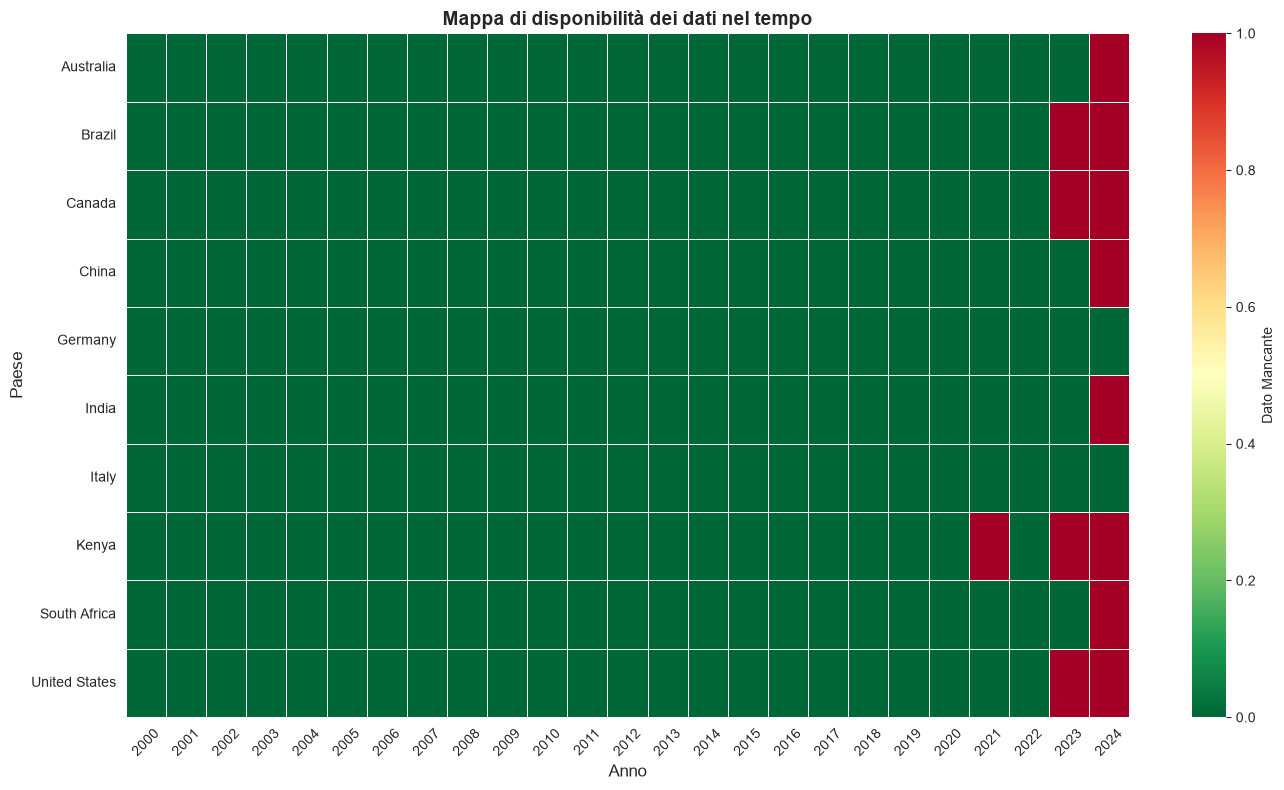

In [7]:
# Visualizza disponibilità dati nel tempo
fig = plot_data_availability(df_ed_raw)
plt.show()

## Education Indicators Analysis

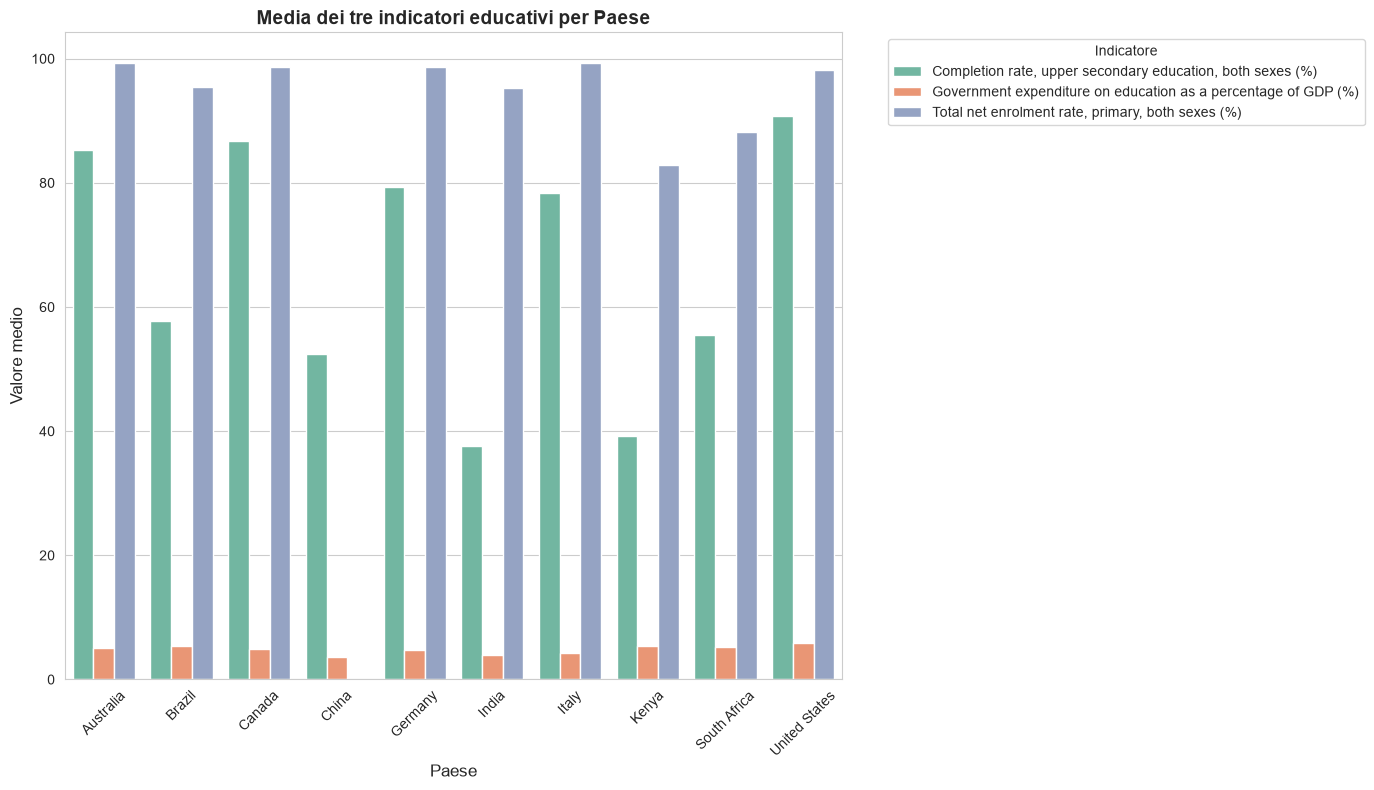

In [8]:
# Media degli indicatori educativi per paese
fig = plot_mean_indicators(df_ed_raw)
plt.show()

In [5]:
# Distribuzione degli indicatori educativi
fig = plot_box_distribution(df_ed_raw)
fig.show()

In [6]:
# Trend degli indicatori nel tempo per ogni paese
fig = plot_trends_by_country(df_ed_raw)
fig.show()

## Correlation Analysis

In [7]:
# Calcola matrice di correlazione
corr_matrix = get_correlation_matrix(df_clean)

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


Correlation Matrix:
                                              Primary Enrolment Rate(%)  \
Primary Enrolment Rate(%)                                         1.000   
Secondary Completion Rate (%)                                     0.557   
Education Expenditure (% of GDP)                                 -0.220   
GDP per Capita                                                    0.504   
Life Expectancy (Years)                                           0.805   
Infant Mortality Rate (per 1000 live births)                     -0.776   

                                              Secondary Completion Rate (%)  \
Primary Enrolment Rate(%)                                             0.557   
Secondary Completion Rate (%)                                         1.000   
Education Expenditure (% of GDP)                                      0.301   
GDP per Capita                                                        0.870   
Life Expectancy (Years)                                   

In [8]:
# Visualizza correlazioni con heatmap
fig = plot_correlation_heatmap(corr_matrix)
fig.show()

In [9]:
# Trova le correlazioni più forti (esclusa la diagonale)
# Converte matrice in formato long
import numpy as np

# Ottieni correlazioni non-diagonali
corr_flat = corr_matrix.values.flatten()
indices = np.argsort(np.abs(corr_flat))[::-1]

print("\nTop 15 Correlazioni (escludendo diagonale):")
print("="*60)

seen = set()
count = 0

for idx in indices:
    if count >= 15:
        break
    
    i = idx // len(corr_matrix.columns)
    j = idx % len(corr_matrix.columns)
    
    if i != j and (i, j) not in seen and (j, i) not in seen:
        seen.add((i, j))
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]
        
        print(f"{count+1:2d}. {col1} <-> {col2}")
        print(f"    r = {value:.3f}\n")
        
        count += 1


Top 15 Correlazioni (escludendo diagonale):
 1. Infant Mortality Rate (per 1000 live births) <-> Life Expectancy (Years)
    r = -0.937

 2. Secondary Completion Rate (%) <-> GDP per Capita
    r = 0.870

 3. Infant Mortality Rate (per 1000 live births) <-> Secondary Completion Rate (%)
    r = -0.853

 4. Secondary Completion Rate (%) <-> Life Expectancy (Years)
    r = 0.808

 5. Life Expectancy (Years) <-> Primary Enrolment Rate(%)
    r = 0.805

 6. Primary Enrolment Rate(%) <-> Infant Mortality Rate (per 1000 live births)
    r = -0.776

 7. Life Expectancy (Years) <-> GDP per Capita
    r = 0.751

 8. GDP per Capita <-> Infant Mortality Rate (per 1000 live births)
    r = -0.713

 9. Primary Enrolment Rate(%) <-> Secondary Completion Rate (%)
    r = 0.557

10. Primary Enrolment Rate(%) <-> GDP per Capita
    r = 0.504

11. Secondary Completion Rate (%) <-> Education Expenditure (% of GDP)
    r = 0.301

12. GDP per Capita <-> Education Expenditure (% of GDP)
    r = 0.267

13. 